In [143]:
# ==========================================================
# FIT5201 — Assignment 1
# Section 3 (Q5): Discriminative vs Generative classifiers
# Author: Rishabh Ray (34525416)
#
# Task:
#   • Compare discriminative (LogReg) vs generative models:
#       Naive Bayes, Bayes (shared cov), Bayes (full cov)
#   • Dataset: Breast cancer (binary classification)
#   • Follow lecture definitions for Gaussian Bayes variants
#
# Allowed libraries: numpy, matplotlib, scikit-learn
# ==========================================================

# ----- Libraries -----
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [145]:
# ==========================================================
# Small utilities (used in Q5 experiments)
# ----------------------------------------------------------
# - Global RNG seed for reproducibility
# - Metrics: classification accuracy and error
# - Feature standardiser: mean/std (ignoring zero-variance)
# ==========================================================
SEED_MAIN = 42
np.random.seed(SEED_MAIN)   # reproducible splits and resampling

# Accuracy = proportion correct
def acc(y_true, y_pred):
    y_true = np.asarray(y_true).ravel().astype(int)
    y_pred = np.asarray(y_pred).ravel().astype(int)
    return float(np.mean(y_true == y_pred))

# Classification error = 1 - accuracy
def err(y_true, y_pred):
    return 1.0 - acc(y_true, y_pred)

# Fit feature standardiser (per-dimension mean, std). Zero std → 1.
def fit_standardizer(X):
    X = np.asarray(X, float)
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=0)
    sd[sd == 0] = 1.0
    return mu, sd

# Apply standardisation: (X - mu) / std
def transform_standardize(X, mu, sd):
    return (np.asarray(X, float) - mu) / sd

In [149]:
# ==========================================================
# Bayes classifiers
# ----------------------------------------------------------
# • Naive Bayes: diagonal covariance per class
# • Bayes (full cov): full Σ per class
# • Bayes (shared cov): pooled Σ across classes
# ==========================================================
def fit_gaussian_nb(X, y, eps=1e-9):
    X = np.asarray(X, float); y = np.asarray(y, int).ravel()
    classes = np.unique(y)
    pri = np.array([np.mean(y == c) for c in classes])
    mu  = np.array([X[y == c].mean(axis=0) for c in classes])
    var = np.array([X[y == c].var(axis=0, ddof=0) + eps for c in classes])  # diag
    return (classes, pri, mu, var)

def predict_gaussian_nb(params, X):
    classes, pri, mu, var = params
    X = np.asarray(X, float)
    logp = []
    for c in range(len(classes)):
        vc = var[c]; mc = mu[c]
        # log N(x|mc, diag(vc)) + log prior
        term = -0.5*np.sum(np.log(2*np.pi*vc)) - 0.5*np.sum((X - mc)**2 / vc, axis=1)
        logp.append(term + np.log(pri[c]))
    logp = np.vstack(logp).T
    return classes[np.argmax(logp, axis=1)]

def fit_bayes_gaussian(X, y, shared=False, eps=1e-6):
    """
    shared=False -> Bayes (full cov)     [per-class full Σ_c]
    shared=True  -> Bayes (shared cov)   [pooled full Σ]
    """
    X = np.asarray(X, float); y = np.asarray(y, int).ravel()
    classes = np.unique(y)
    pri = np.array([np.mean(y == c) for c in classes])
    mu  = np.array([X[y == c].mean(axis=0) for c in classes])
    d = X.shape[1]

    if shared:
        # pooled covariance across classes
        S = np.zeros((d, d))
        for ci, c in enumerate(classes):
            Xc = X[y == c] - mu[ci]
            S += Xc.T @ Xc
        S /= X.shape[0]
        S = S + eps*np.eye(d)
        inv = np.linalg.inv(S)
        _, ld = np.linalg.slogdet(S)
        return (classes, pri, mu, inv, ld)  # shared Σ
    else:
        # per-class covariance
        covs = np.stack([np.cov(X[y == c].T, bias=True) for c in classes], axis=0)
        covs = covs + eps*np.eye(d)[None, :, :]
        inv = np.linalg.inv(covs)
        _, logdet = np.linalg.slogdet(covs)
        return (classes, pri, mu, inv, logdet)  # Σ_c

def predict_bayes_gaussian(params, X):
    X = np.asarray(X, float)
    classes, pri, mu, inv, logdet = params
    scores = []
    shared = isinstance(inv, np.ndarray) and inv.ndim == 2  # shared Σ vs per-class Σ_c
    for c in range(len(classes)):
        d = X - mu[c]
        if shared:
            quad = np.einsum('ij,jk,ik->i', d, inv, d)
            ld = logdet
        else:
            quad = np.einsum('ij,jk,ik->i', d, inv[c], d)
            ld = logdet[c]
        scores.append(-0.5*(ld + quad) + np.log(pri[c]))
    scores = np.vstack(scores).T
    return classes[np.argmax(scores, axis=1)]

In [151]:
# ==========================================================
# Dataset (Q5)
# ----------------------------------------------------------
# Using sklearn breast_cancer dataset (binary classification).
# Features: 30 real-valued attributes
# Labels: malignant (0), benign (1)
# ==========================================================
X, y = load_breast_cancer(return_X_y=True)

In [153]:
# ==========================================================
# Q5.I — Single 80/20 split evaluation
# ----------------------------------------------------------
# Procedure:
#   • Split breast cancer dataset (80% train, 20% test, stratified)
#   • Train discriminative (LogReg) with standardisation
#   • Train generative models (Naive Bayes, Bayes full cov, Bayes shared cov)
#   • Report train/test accuracy and error for each model
# ==========================================================
# Train/test split (stratified)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, train_size=0.8, shuffle=True, stratify=y, random_state=2
)

# Logistic Regression (with standardisation)
mu, sd = fit_standardizer(X_tr)
Xtr_s = transform_standardize(X_tr, mu, sd)
Xte_s = transform_standardize(X_te, mu, sd)
logreg = LogisticRegression(max_iter=5000, solver='lbfgs',
                            random_state=SEED_MAIN).fit(Xtr_s, y_tr)

# Generative models (raw features)
nb_params    = fit_gaussian_nb(X_tr, y_tr)                  # Naive Bayes (diag cov)
bayes_full   = fit_bayes_gaussian(X_tr, y_tr, shared=False) # Bayes (full cov)
bayes_shared = fit_bayes_gaussian(X_tr, y_tr, shared=True)  # Bayes (shared cov)

# Evaluate all four models on train/test
def eval_q5i():
    out_acc = {}

    # LogReg
    yp_tr = logreg.predict(Xtr_s); yp_te = logreg.predict(Xte_s)
    out_acc['LogReg_tr'] = acc(y_tr, yp_tr)
    out_acc['LogReg_te'] = acc(y_te, yp_te)

    # Naive Bayes
    yp_tr = predict_gaussian_nb(nb_params, X_tr)
    yp_te = predict_gaussian_nb(nb_params, X_te)
    out_acc['Naive Bayes_tr'] = acc(y_tr, yp_tr)
    out_acc['Naive Bayes_te'] = acc(y_te, yp_te)

    # Bayes (full cov)
    yp_tr = predict_bayes_gaussian(bayes_full, X_tr)
    yp_te = predict_bayes_gaussian(bayes_full, X_te)
    out_acc['Bayes (full cov)_tr'] = acc(y_tr, yp_tr)
    out_acc['Bayes (full cov)_te'] = acc(y_te, yp_te)

    # Bayes (shared cov)
    yp_tr = predict_bayes_gaussian(bayes_shared, X_tr)
    yp_te = predict_bayes_gaussian(bayes_shared, X_te)
    out_acc['Bayes (shared cov)_tr'] = acc(y_tr, yp_tr)
    out_acc['Bayes (shared cov)_te'] = acc(y_te, yp_te)

    # Also provide errors
    out_err = {k.replace('acc', 'err'): 1.0 - v for k, v in out_acc.items()}
    return out_acc, out_err

# Run Q5.I evaluation
res_acc, res_err = eval_q5i()

# Print results (accuracy)
print("=== Q5.I — Train/Test Accuracy ===")
for m in ['LogReg','Naive Bayes','Bayes (full cov)','Bayes (shared cov)']:
    print(f"{m:>18}  train_acc={res_acc[f'{m}_tr']:.4f}  test_acc={res_acc[f'{m}_te']:.4f}")

# Print results (error)
print("\n=== Q5.I — Train/Test Error (1-acc) ===")
for m in ['LogReg','Naive Bayes','Bayes (full cov)','Bayes (shared cov)']:
    print(f"{m:>18}  train_err={1.0-res_acc[f'{m}_tr']:.4f}  test_err={1.0-res_acc[f'{m}_te']:.4f}")

# Identify best models
best_train = max(['LogReg','Naive Bayes','Bayes (full cov)','Bayes (shared cov)'],
                 key=lambda m: res_acc[f'{m}_tr'])
best_test  = max(['LogReg','Naive Bayes','Bayes (full cov)','Bayes (shared cov)'],
                 key=lambda m: res_acc[f'{m}_te'])
print(f"\nQ5.I — Best on TRAIN: {best_train} | Best on TEST: {best_test}")

=== Q5.I — Train/Test Accuracy ===
            LogReg  train_acc=0.9890  test_acc=0.9825
       Naive Bayes  train_acc=0.9407  test_acc=0.9649
  Bayes (full cov)  train_acc=0.9714  test_acc=0.9737
Bayes (shared cov)  train_acc=0.9670  test_acc=0.9649

=== Q5.I — Train/Test Error (1-acc) ===
            LogReg  train_err=0.0110  test_err=0.0175
       Naive Bayes  train_err=0.0593  test_err=0.0351
  Bayes (full cov)  train_err=0.0286  test_err=0.0263
Bayes (shared cov)  train_err=0.0330  test_err=0.0351

Q5.I — Best on TRAIN: LogReg | Best on TEST: LogReg


In [155]:
# ==========================================================
# Q5.II — Learning curves vs training size N (R=10 resamples)
# ----------------------------------------------------------
# Procedure:
#   • Fix a test set (20%)
#   • For each N in {5,10,...,500}, sample N training points (stratified)
#   • Repeat R=10 times per N (ensure both classes appear)
#   • Train/evaluate all models on identical resamples
#   • Record mean train/test accuracy and error across repetitions
# ==========================================================
# Hold-out pool and fixed test set
X_pool, X_test_fixed, y_pool, y_test_fixed = train_test_split(
    X, y, train_size=0.8, shuffle=True, stratify=y, random_state=42
)

# Training sizes and repetitions
Ns = np.arange(5, 501, 5)
Ns = Ns[Ns < len(X_pool)]
R = 10

# Storage for curves (per model × train/test)
keys = ['LogReg_tr','LogReg_te',
        'Naive Bayes_tr','Naive Bayes_te',
        'Bayes (full cov)_tr','Bayes (full cov)_te',
        'Bayes (shared cov)_tr','Bayes (shared cov)_te']
curves_err = {k: [] for k in keys}
curves_acc = {k: [] for k in keys}

# Fit/evaluate all models on given train/test
def eval_all_models(Xtr, ytr, Xte, yte):
    A, E = {}, {}

    # LogReg (with standardisation)
    mu, sd = fit_standardizer(Xtr)
    Xtr_s = transform_standardize(Xtr, mu, sd)
    Xte_s = transform_standardize(Xte, mu, sd)
    lr = LogisticRegression(max_iter=5000, solver='lbfgs',
                            random_state=SEED_MAIN).fit(Xtr_s, ytr)
    for tag, Xs, ys in [('tr', Xtr_s, ytr), ('te', Xte_s, yte)]:
        yp = lr.predict(Xs)
        A['LogReg_'+tag] = acc(ys, yp)
        E['LogReg_'+tag] = err(ys, yp)

    # Naive Bayes (diagonal cov per class)
    nbp = fit_gaussian_nb(Xtr, ytr)
    for tag, Xs, ys in [('tr', Xtr, ytr), ('te', Xte, yte)]:
        yp = predict_gaussian_nb(nbp, Xs)
        A['Naive Bayes_'+tag] = acc(ys, yp)
        E['Naive Bayes_'+tag] = err(ys, yp)

    # Bayes (full covariance per class)
    bf = fit_bayes_gaussian(Xtr, ytr, shared=False)
    for tag, Xs, ys in [('tr', Xtr, ytr), ('te', Xte, yte)]:
        yp = predict_bayes_gaussian(bf, Xs)
        A['Bayes (full cov)_'+tag] = acc(ys, yp)
        E['Bayes (full cov)_'+tag] = err(ys, yp)

    # Bayes (shared covariance across classes)
    bs = fit_bayes_gaussian(Xtr, ytr, shared=True)
    for tag, Xs, ys in [('tr', Xtr, ytr), ('te', Xte, yte)]:
        yp = predict_bayes_gaussian(bs, Xs)
        A['Bayes (shared cov)_'+tag] = acc(ys, yp)
        E['Bayes (shared cov)_'+tag] = err(ys, yp)

    return A, E

# Loop over training sizes N
for N in Ns:
    stats_acc = {k: [] for k in curves_acc}
    stats_err = {k: [] for k in curves_err}

    for r in range(R):
        # Resample training set (ensure both classes present)
        ok = False
        for t in range(20):
            Xtr_sub, _, ytr_sub, _ = train_test_split(
                X_pool, y_pool, train_size=N, shuffle=True, stratify=y_pool,
                random_state=10_000 + r + 97*N + t
            )
            if len(np.unique(ytr_sub)) == 2:
                ok = True
                break
        if not ok:
            continue

        # Evaluate all models
        A, E = eval_all_models(Xtr_sub, ytr_sub, X_test_fixed, y_test_fixed)
        for k in stats_acc: stats_acc[k].append(A[k])
        for k in stats_err: stats_err[k].append(E[k])

    # Store mean performance across repetitions
    for k in curves_acc:
        curves_acc[k].append(np.mean(stats_acc[k]) if stats_acc[k] else np.nan)
        curves_err[k].append(np.mean(stats_err[k]) if stats_err[k] else np.nan)

print("\nQ5.II — Collected mean train/test accuracy and error across N.")


Q5.II — Collected mean train/test accuracy and error across N.


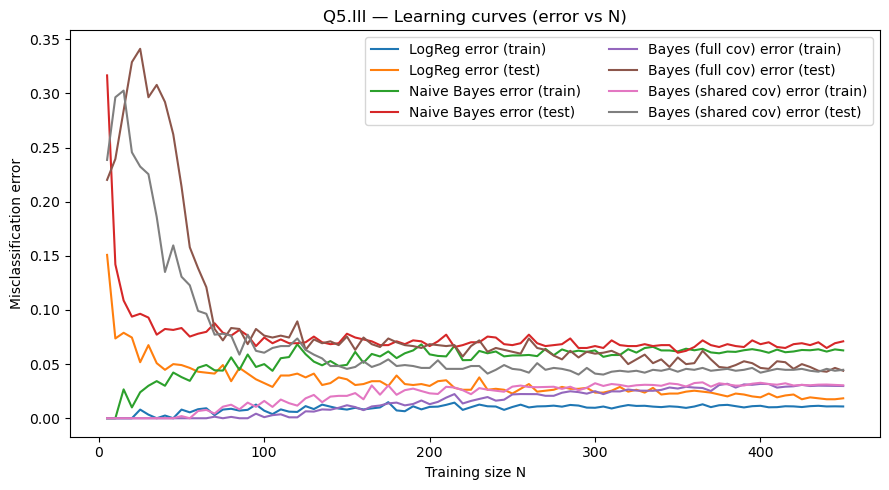

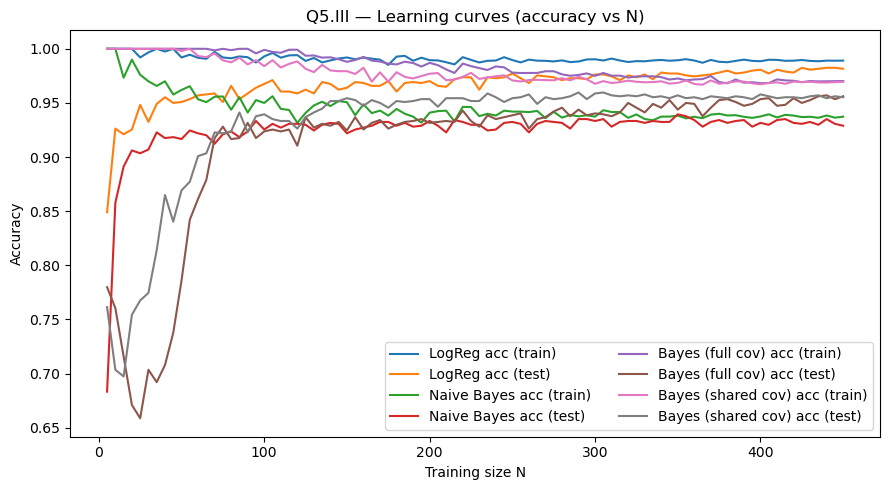

In [157]:
# ==========================================================
# Q5.III — Learning curves (train/test error and accuracy)
# ----------------------------------------------------------
# Plot mean results (from Q5.II) across training sizes N:
#   • Misclassification error vs N
#   • Accuracy vs N
# Each model shown with separate curves (train vs test).
# ==========================================================
# Error view
plt.figure(figsize=(9,5))
plt.plot(Ns, curves_err['LogReg_tr'],              label='LogReg error (train)')
plt.plot(Ns, curves_err['LogReg_te'],              label='LogReg error (test)')
plt.plot(Ns, curves_err['Naive Bayes_tr'],         label='Naive Bayes error (train)')
plt.plot(Ns, curves_err['Naive Bayes_te'],         label='Naive Bayes error (test)')
plt.plot(Ns, curves_err['Bayes (full cov)_tr'],    label='Bayes (full cov) error (train)')
plt.plot(Ns, curves_err['Bayes (full cov)_te'],    label='Bayes (full cov) error (test)')
plt.plot(Ns, curves_err['Bayes (shared cov)_tr'],  label='Bayes (shared cov) error (train)')
plt.plot(Ns, curves_err['Bayes (shared cov)_te'],  label='Bayes (shared cov) error (test)')
plt.xlabel("Training size N")
plt.ylabel("Misclassification error")
plt.title("Q5.III — Learning curves (error vs N)")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# Accuracy view
plt.figure(figsize=(9,5))
plt.plot(Ns, curves_acc['LogReg_tr'],              label='LogReg acc (train)')
plt.plot(Ns, curves_acc['LogReg_te'],              label='LogReg acc (test)')
plt.plot(Ns, curves_acc['Naive Bayes_tr'],         label='Naive Bayes acc (train)')
plt.plot(Ns, curves_acc['Naive Bayes_te'],         label='Naive Bayes acc (test)')
plt.plot(Ns, curves_acc['Bayes (full cov)_tr'],    label='Bayes (full cov) acc (train)')
plt.plot(Ns, curves_acc['Bayes (full cov)_te'],    label='Bayes (full cov) acc (test)')
plt.plot(Ns, curves_acc['Bayes (shared cov)_tr'],  label='Bayes (shared cov) acc (train)')
plt.plot(Ns, curves_acc['Bayes (shared cov)_te'],  label='Bayes (shared cov) acc (test)')
plt.xlabel("Training size N")
plt.ylabel("Accuracy")
plt.title("Q5.III — Learning curves (accuracy vs N)")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# Q5.IV

**(a)**  
As training size *N* increases, training error rises and test error falls then plateaus.  
The gap between training and test error shrinks as *N* grows.

**(b)**  
**Best model depending on N:**  
- **Small N:** Bayes (shared cov) or LogReg perform best due to lower variance.  
- **Large N:** Bayes (full cov) can match or exceed performance if class covariances differ. Otherwise Bayes (shared cov) and LogReg remain competitive.  
- **Naive Bayes:** Can only outperform others at very small N if its independence assumption happens to fit the data.

**(c)**  
**Reasons for differences:**  
- **Bayes (full cov):** Uses per-class full covariance matrices. This means many parameters, high variance, and a need for large *N* to estimate reliably.  
- **Bayes (shared cov):** Pools covariance across classes. Fewer parameters, lower variance, more stable with smaller *N*.  
- **LogReg:** Directly learns a linear decision boundary without modeling densities. More data-efficient, robust at moderate sample sizes.  
- **Naive Bayes:** Assumes feature independence. This introduces bias but keeps variance very low, so it can work well when *N* is tiny but breaks down as dependencies matter.
